In [1]:
import torch
import torch.nn as nn
from datasets import load_dataset
from torch.utils.data import DataLoader
from torch.utils.data import Dataset, DataLoader
from transformer import Transformer

In [2]:
torch.backends.cudnn.enabled = False
print("cudnn enabled:", torch.backends.cudnn.enabled)

cudnn enabled: False


In [3]:
ds = load_dataset("TimSchopf/arxiv_categories", "default")

train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

In [4]:
ds

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'abstract', 'categories', 'creation_date'],
        num_rows: 163168
    })
    validation: Dataset({
        features: ['id', 'title', 'abstract', 'categories', 'creation_date'],
        num_rows: 20396
    })
    test: Dataset({
        features: ['id', 'title', 'abstract', 'categories', 'creation_date'],
        num_rows: 20397
    })
})

In [5]:
print(train_df.columns.tolist())
print(train_df.head(3))

['id', 'title', 'abstract', 'categories', 'creation_date']
           id                                              title  \
0  2204.14117  A Comparative Study of Meter Detection Methods...   
1  2305.19887  The Markov chain embedding problem in a low ju...   
2   0910.5857  Chaotic Transport and Chronology of Complex As...   

                                            abstract  \
0  In order to read meter values from a camera on...   
1  We consider the problem of finding the transit...   
2  We present a transport model that describes th...   

                                 categories             creation_date  
0         [Computer Science Archive->cs.CV] 2022-04-24 13:59:57+00:00  
1            [Mathematics Archive->math.PR] 2023-05-31 14:24:25+00:00  
2  [Physics Archive->astro-ph->astro-ph.EP] 2009-10-30 12:34:26+00:00  


In [6]:
print(train_df["categories"][0])

['Computer Science Archive->cs.CV']


In [7]:
def normalize_categories(categories):
    for cat in categories:
        if cat.startswith("Computer Science Archive"):
            return "computer_science"
        elif cat.startswith("Mathematics Archive"):
            return "mathematics"
        elif cat.startswith("Physics Archive"):
            return "physics"
            
    return None

In [8]:
train_df.head(3)

,id,title,abstract,categories,creation_date
0,2204.14117,A Comparative Study of Meter Detection Methods...,In order to read meter values from a camera on...,[Computer Science Archive->cs.CV],2022-04-24 13:59:57+00:00
1,2305.19887,The Markov chain embedding problem in a low ju...,We consider the problem of finding the transit...,[Mathematics Archive->math.PR],2023-05-31 14:24:25+00:00
2,0910.5857,Chaotic Transport and Chronology of Complex As...,We present a transport model that describes th...,[Physics Archive->astro-ph->astro-ph.EP],2009-10-30 12:34:26+00:00


In [9]:
train_df["label"] = train_df["categories"].apply(normalize_categories)
val_df["label"] = val_df["categories"].apply(normalize_categories)
test_df["label"] = test_df["categories"].apply(normalize_categories)

train_df = train_df[train_df["label"].notna()].copy()
val_df = val_df[val_df["label"].notna()].copy()
test_df = test_df[test_df["label"].notna()].copy()

In [10]:
train_df.head(3)

,id,title,abstract,categories,creation_date,label
0,2204.14117,A Comparative Study of Meter Detection Methods...,In order to read meter values from a camera on...,[Computer Science Archive->cs.CV],2022-04-24 13:59:57+00:00,computer_science
1,2305.19887,The Markov chain embedding problem in a low ju...,We consider the problem of finding the transit...,[Mathematics Archive->math.PR],2023-05-31 14:24:25+00:00,mathematics
2,0910.5857,Chaotic Transport and Chronology of Complex As...,We present a transport model that describes th...,[Physics Archive->astro-ph->astro-ph.EP],2009-10-30 12:34:26+00:00,physics


In [11]:
print(train_df["label"].value_counts())
print(val_df["label"].value_counts())
print(test_df["label"].value_counts())

label
physics             92506
mathematics         33816
computer_science    32994
Name: count, dtype: int64
label
physics             11558
mathematics          4231
computer_science     4124
Name: count, dtype: int64
label
physics             11565
mathematics          4223
computer_science     4129
Name: count, dtype: int64


In [12]:
label2id = {
    "computer_science": 0,
    "mathematics": 1,
    "physics": 2
}

id2label = {val: key for key, val in label2id.items()}

train_df["label_id"] = train_df["label"].map(label2id)
val_df["label_id"] = val_df["label"].map(label2id)
test_df["label_id"] = test_df["label"].map(label2id)

In [13]:
class MyDataset(Dataset):
    def __init__(self, df, tokenizer, text_col = "abstract", label_col="label_id", max_len=256):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.text_col = text_col
        self.label_col = label_col
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = str(self.df.iloc[idx][self.text_col])
        label = int(self.df.iloc[idx][self.label_col])
        tokenized = self.tokenizer(
            text, 
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_attention_mask=True
        )
        return {"input_ids": torch.tensor(tokenized["input_ids"],dtype=torch.long), 
                "attention_mask": torch.tensor(tokenized["attention_mask"],dtype=torch.long),
                "labels": torch.tensor(label, dtype=torch.long)
               }
        

In [14]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [15]:
train_dataset = MyDataset(train_df, tokenizer)
val_dataset = MyDataset(val_df, tokenizer)
test_dataset = MyDataset(test_df, tokenizer)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [16]:
batch = next(iter(train_loader))
print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

torch.Size([32, 256])
torch.Size([32, 256])
torch.Size([32])


In [17]:
batch = next(iter(train_loader))
print(batch["input_ids"])

tensor([[ 101, 2057, 2556,  ...,    0,    0,    0],
        [ 101, 2057, 2556,  ...,    0,    0,    0],
        [ 101, 1996, 4100,  ...,    0,    0,    0],
        ...,
        [ 101, 2007, 1037,  ...,    0,    0,    0],
        [ 101, 2057, 2556,  ..., 1996, 2898,  102],
        [ 101, 2057, 2265,  ...,    0,    0,    0]])


**Обучим трансформер для классификации текста**

In [44]:
vocab_size = tokenizer.vocab_size
pad_token_id = tokenizer.pad_token_id
num_classes = 3

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [46]:
model = Transformer(
    vocab_size=vocab_size,
    max_len=256,
    num_classes=num_classes,
    d_model=128,
    num_heads=4,
    num_layers=2,
    d_feed_forward=512,
    dropout=0.1,
    pad_token_id=pad_token_id,
).to(device)

In [47]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()

In [48]:
batch = next(iter(train_loader))
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)

logits = model(input_ids, attention_mask)
print(logits.shape)

torch.Size([32, 3])


In [49]:
def eval_model(model, loader):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    correct = 0
    
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
    
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
    
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size
    
            predictions = logits.argmax(dim=1)
            correct += (predictions == labels).sum().item()
    
    mean_loss = total_loss / total_samples
    accuracy = correct / total_samples
    return accuracy, mean_loss

In [50]:
epoch_loss_val_list = []
epoch_loss_train_list = []
accuracy_val_list = []
accuracy_train_list = []

In [43]:
import time

start_time = time.time()

num_epochs = 10
model.to(device)
for epoch in range(1, num_epochs + 1):
    epoch_start_time = time.time()
    model.train()

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()
    accuracy_val, mean_loss_val = eval_model(model, val_loader)
    accuracy_train, mean_loss_train = eval_model(model, train_loader)
    
    epoch_loss_val_list.append(mean_loss_val)
    epoch_loss_train_list.append(mean_loss_train)
    
    accuracy_val_list.append(accuracy_val)
    accuracy_train_list.append(accuracy_train)
    print(f"Epoch {epoch}/{num_epochs}, val accuracy: {accuracy_val:.4f}, test loss: {mean_loss_val:.4f}, epoch time = {(time.time() - epoch_start_time):.2f} sec.")

print(f"Суммарное время обучения: {(time.time() - start_time):.2f} sec.")

Epoch 1/5, accuracy: 0.9216, train loss: 0.2210, epoch time = 91.38 sec.
Epoch 2/5, accuracy: 0.9305, train loss: 0.1928, epoch time = 91.19 sec.
Epoch 3/5, accuracy: 0.9298, train loss: 0.1919, epoch time = 90.48 sec.
Epoch 4/5, accuracy: 0.9378, train loss: 0.1697, epoch time = 90.19 sec.
Epoch 5/5, accuracy: 0.9400, train loss: 0.1640, epoch time = 92.99 sec.
Суммарное время обучения: 456.23 sec.


In [28]:
accuracy

0.9334605534073218

In [51]:
import time

start_time = time.time()

num_epochs = 10
model.to(device)
for epoch in range(1, num_epochs + 1):
    epoch_start_time = time.time()
    model.train()

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()
    accuracy_val, mean_loss_val = eval_model(model, val_loader)
    accuracy_train, mean_loss_train = eval_model(model, train_loader)
    
    epoch_loss_val_list.append(mean_loss_val)
    epoch_loss_train_list.append(mean_loss_train)
    
    accuracy_val_list.append(accuracy_val)
    accuracy_train_list.append(accuracy_train)
    print(f"Epoch {epoch}/{num_epochs}, val accuracy: {accuracy_val:.4f}, test loss: {mean_loss_val:.4f}, epoch time = {(time.time() - epoch_start_time):.2f} sec.")

print(f"Суммарное время обучения: {(time.time() - start_time):.2f} sec.")

Epoch 1/10, val accuracy: 0.9365, test loss: 0.1758, epoch time = 170.62 sec.
Epoch 2/10, val accuracy: 0.9422, test loss: 0.1554, epoch time = 170.69 sec.
Epoch 3/10, val accuracy: 0.9476, test loss: 0.1464, epoch time = 170.80 sec.
Epoch 4/10, val accuracy: 0.9404, test loss: 0.1737, epoch time = 171.60 sec.
Epoch 5/10, val accuracy: 0.9480, test loss: 0.1527, epoch time = 172.07 sec.
Epoch 6/10, val accuracy: 0.9475, test loss: 0.1593, epoch time = 172.15 sec.
Epoch 7/10, val accuracy: 0.9463, test loss: 0.1739, epoch time = 172.85 sec.
Epoch 8/10, val accuracy: 0.9444, test loss: 0.1839, epoch time = 173.38 sec.
Epoch 9/10, val accuracy: 0.9436, test loss: 0.1962, epoch time = 172.78 sec.
Epoch 10/10, val accuracy: 0.9412, test loss: 0.2137, epoch time = 171.24 sec.
Суммарное время обучения: 1718.19 sec.


In [52]:
torch.save(model.state_dict(), "transformer_weights.pt")

In [53]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "vocab_size": vocab_size,
    "max_len": 256,
    "num_classes": num_classes,
    "d_model": 128,
    "num_heads": 4,
    "num_layers": 2,
    "d_feed_forward": 512,
    "dropout": 0.1,
    "pad_token_id": pad_token_id,
    "label2id": label2id,
    "id2label": id2label,
}

torch.save(checkpoint, "transformer_checkpoint.pt")

In [ ]:
epoch_loss_val_list
epoch_loss_train_list 
accuracy_val_list
accuracy_train_list

In [55]:
import matplotlib.pyplot as plt

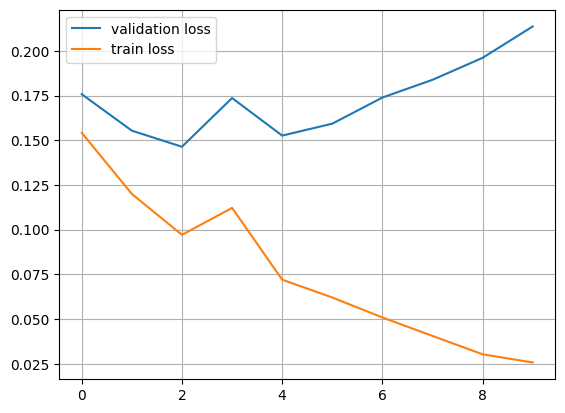

In [60]:
epoches = list(range(num_epochs))
plt.plot(epoches, epoch_loss_val_list, label="validation loss")
plt.plot(epoches, epoch_loss_train_list, label="train loss")
plt.legend()
plt.grid()

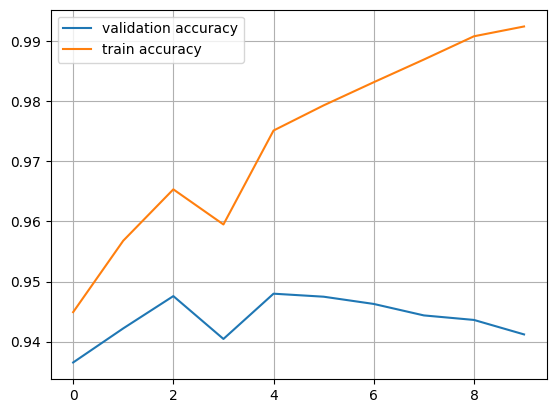

In [59]:
plt.plot(epoches, accuracy_val_list, label="validation accuracy")
plt.plot(epoches, accuracy_train_list, label="train accuracy")
plt.legend()
plt.grid()

Видим, что оптимальное количество эпох 2, а далее модель переобучается. Впрочем, ее результат слабо изменяется и составляет ~94% accuracy.
Посмотрим на macro f1 score, который может быть более актуален в случае несбалансированной выборки.

In [67]:
import torch
from sklearn.metrics import accuracy_score, f1_score


def eval_model(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            predictions = logits.argmax(dim=1)

            all_labels.extend(labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())

    mean_loss = total_loss / total_samples
    accuracy = accuracy_score(all_labels, all_predictions)
    macro_f1 = f1_score(all_labels, all_predictions, average="macro")

    print(f"mean_loss = {mean_loss}")
    print(f"accuracy = {accuracy}")
    print(f"macro_f1 = {macro_f1}")
    # return mean_loss, accuracy, macro_f1

In [68]:
eval_model(model, val_loader, criterion, device)

mean_loss = 0.21370956512945571
accuracy = 0.94119419474715
macro_f1 = 0.925535955039336
